In [1]:
import logging
from nlab_modbus.manager import DeviceManager
import time
import matplotlib.pyplot as plt


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    force=True
)
logging.getLogger("pymodbus").setLevel(logging.CRITICAL)
logging.getLogger("pymodbus.logging").setLevel(logging.CRITICAL)


In [2]:
mgr = DeviceManager()

In [3]:
ips = await mgr.scan_remote_ips_async()
print(ips)

['192.168.10.128', '192.168.10.134']


In [4]:
mgr.scan_local_ports()

2026-06-01 13:05:25,908 | INFO     | nlab_modbus.discovery.scan | Register found: 257


In [5]:
mgr.local

In [6]:
mgr.local[0].connection_info()

'serial://COM6:1'

In [7]:
mgr.local[0].get_board_temp()

29.19

In [8]:
for ip in ips:
    mgr.scan_remote(ip, [5001, 5002])

2026-06-01 13:05:31,865 | INFO     | nlab_modbus.discovery.scan | Register found: 769
2026-06-01 13:05:33,898 | INFO     | nlab_modbus.discovery.scan | Register found: 257
2026-06-01 13:05:33,931 | INFO     | nlab_modbus.discovery.scan | Register found: 513


In [9]:
mgr.remote

In [10]:
mgr.remote[0].set_pwm_enable(1)

In [11]:
mgr.all_devices

In [12]:
mgr.close_all()

In [13]:
mgr.local[0].connect()

In [14]:
temps = []
counts = []
times = []
t0 = time.monotonic()
dt = 0.22
next_time = t0 + dt  # Absolute target for first
while next_time - t0 < 15:
    temp = mgr.local[0].get_board_temp()
    cps = mgr.remote[2].get_pulses_per_sec()
    temps.append(temp)
    counts.append(cps)
    times.append(time.monotonic() - t0)
    print(f"{times[-1]:8.2f} s, {temp:7.2f} °C, {cps:6d} cps", end="\r")
    next_time += dt
    sleep_dur = next_time - time.monotonic()
    if sleep_dur > 0:
        time.sleep(sleep_dur)

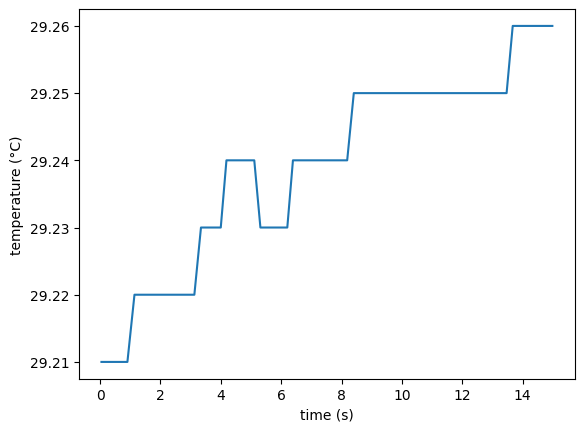

In [15]:
plt.figure()
plt.plot(times, temps)
plt.xlabel('time (s)')
plt.ylabel('temperature (°C)')
plt.show()

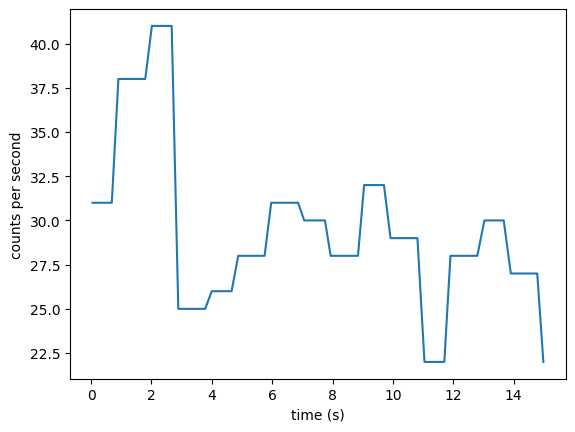

In [16]:
plt.figure()
plt.plot(times, counts)
plt.xlabel('time (s)')
plt.ylabel('counts per second')
plt.show()

In [17]:
import numpy as np

In [18]:
np.array(times[1:]) - np.array(times[:-1])

array([0.422, 0.219, 0.219, 0.234, 0.219, 0.187, 0.25 , 0.219, 0.219,
       0.234, 0.203, 0.219, 0.234, 0.219, 0.188, 0.25 , 0.218, 0.188,
       0.25 , 0.219, 0.218, 0.235, 0.203, 0.234, 0.203, 0.219, 0.235,
       0.187, 0.25 , 0.219, 0.203, 0.219, 0.234, 0.234, 0.188, 0.25 ,
       0.219, 0.187, 0.25 , 0.203, 0.219, 0.234, 0.204, 0.218, 0.235,
       0.234, 0.203, 0.219, 0.234, 0.219, 0.188, 0.25 , 0.203, 0.218,
       0.235, 0.203, 0.234, 0.235, 0.187, 0.25 , 0.203, 0.235, 0.203,
       0.219, 0.218, 0.235, 0.203])

(array([ 8.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 11.,  1.,  0.,  0.,  0.,
         0.,  0.,  0.,  5., 16.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 10.,
         7.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  8.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.187     , 0.18883594, 0.19067187, 0.19250781, 0.19434375,
        0.19617969, 0.19801562, 0.19985156, 0.2016875 , 0.20352344,
        0.20535937, 0.20719531, 0.20903125, 0.21086719, 0.21270312,
        0.21453906, 0.216375  , 0.21821094, 0.22004687, 0.22188281,
      

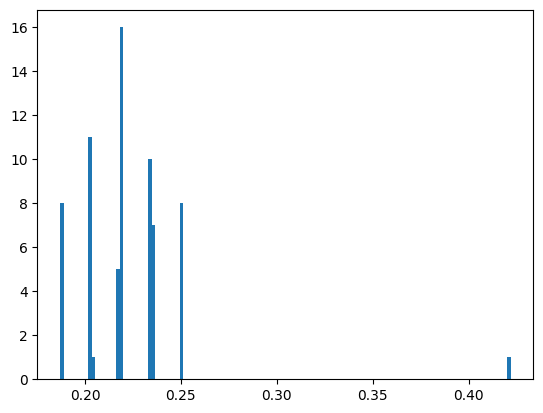

In [19]:
plt.hist(np.array(times[1:]) - np.array(times[:-1]), bins=128)

In [20]:
mgr.local[0]

In [21]:
result = mgr.local[0].read_snapshot()

In [22]:
print(result)

{'sipm_voltage_10mv': 0.31, 'sipm_current_ua': 0.0, 'board_temp_adc': 28.55, 'usb_rx_frames_cnt': 11754.0, 'usb_rx_crc_err_cnt': 5.0, 'usb_rx_bad_req_cnt': 8.0, 'cpu_temp': 32.0, 'board_temp': 29.26, 'eeprom_error': 0.0, 'supply_voltage': 4.92, 'adc_sipm_vout': 0.4, 'sipm_board_temp': -300.0, 'sipm_correct_voltage_mv': 0.0, 'vout_supply_fault': 0.0, 'ext_amp_supply_fault': 0.0, 'led_drv_temp': 30.0, 'led_drv_status': 0.0, 'vout_ripple': 7.0, 'pid_saturation': 0.0}


In [23]:
from nlab_modbus.core.register_specs import RegisterType
from nlab_modbus.devices.sipm import SiPMDevice

In [24]:
mgr.local[0]._register_index[(RegisterType.HOLDING, 3)]

('vout_set',
 RegisterSpec(reg_type=<RegisterType.HOLDING: 'holding'>, address=3, dtype='uint16', min=1500, max=7800, count=1, scale=0.01, unit='mV'))

In [25]:
count = SiPMDevice.READOUT_STOP - SiPMDevice.READOUT_START

In [26]:
count

19

In [27]:
registers = mgr.local[0].read_raw_block(address=SiPMDevice.READOUT_START, count=count)

In [28]:
registers

[31, 0, 2855, 11755, 5, 8, 33, 2926, 0, 492, 40, 35536, 0, 0, 0, 30, 0, 7, 0]

In [29]:
test = mgr.local[0].client.read_input_registers(
            address=SiPMDevice.READOUT_START,
            count=count,
            device_id=mgr.local[0].device_id,
        )

In [30]:
test

In [31]:
test.registers

[31, 0, 2854, 11756, 5, 8, 33, 2926, 0, 491, 40, 35536, 0, 0, 0, 30, 0, 7, 0]

In [32]:
result = mgr.local[0].read_snapshot()
for key, value in result.items():
    print(key, value)

sipm_voltage_10mv 0.31
sipm_current_ua 0.0
board_temp_adc 28.53
usb_rx_frames_cnt 11757.0
usb_rx_crc_err_cnt 5.0
usb_rx_bad_req_cnt 8.0
cpu_temp 32.0
board_temp 29.26
eeprom_error 0.0
supply_voltage 4.91
adc_sipm_vout 0.4
sipm_board_temp -300.0
sipm_correct_voltage_mv 0.0
vout_supply_fault 0.0
ext_amp_supply_fault 0.0
led_drv_temp 30.0
led_drv_status 0.0
vout_ripple 7.0
pid_saturation 0.0


In [33]:
labels = list(mgr.local[0].read_snapshot().keys())

In [34]:
print(labels)

['sipm_voltage_10mv', 'sipm_current_ua', 'board_temp_adc', 'usb_rx_frames_cnt', 'usb_rx_crc_err_cnt', 'usb_rx_bad_req_cnt', 'cpu_temp', 'board_temp', 'eeprom_error', 'supply_voltage', 'adc_sipm_vout', 'sipm_board_temp', 'sipm_correct_voltage_mv', 'vout_supply_fault', 'ext_amp_supply_fault', 'led_drv_temp', 'led_drv_status', 'vout_ripple', 'pid_saturation']


In [36]:
buffer = {lbl: [] for lbl in labels}
times = []
t0 = time.monotonic()
dt = 0.22
next_time = t0 + dt  # Absolute target for first
time_limit = 10
while next_time - t0 < time_limit:
    stats = mgr.local[0].read_snapshot()
    for key, value in stats.items():
        buffer[key].append(value)
    times.append(time.monotonic() - t0)
    print(f"{times[-1]:8.2f} s, measuring for {time_limit:8.2f}", end='\r')
    next_time += dt
    sleep_dur = next_time - time.monotonic()
    if sleep_dur > 0:
        time.sleep(sleep_dur)

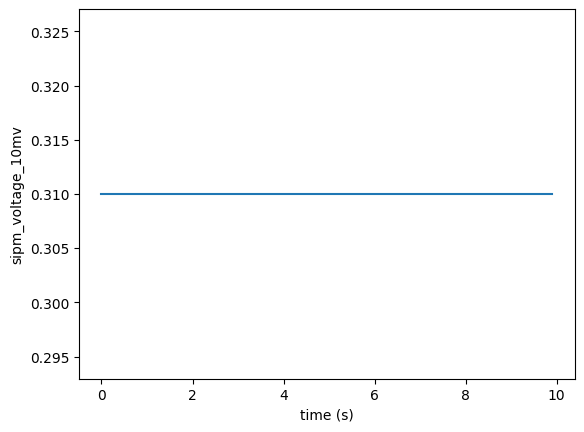

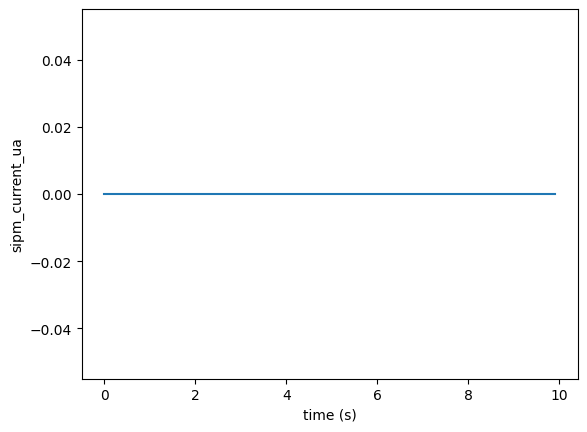

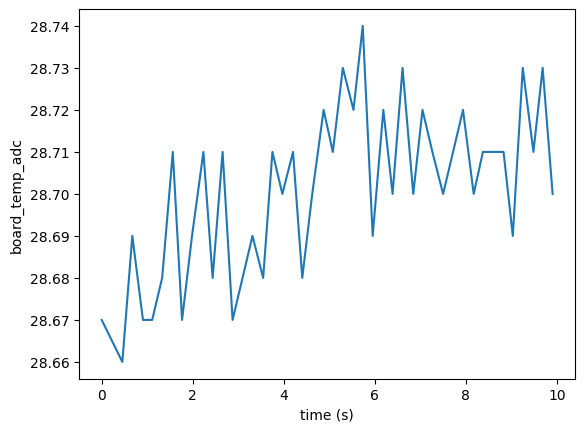

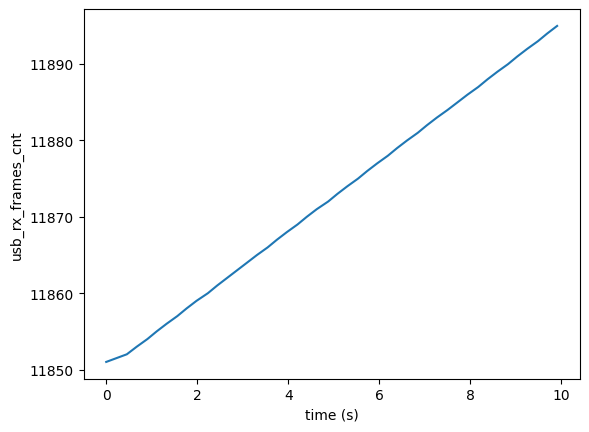

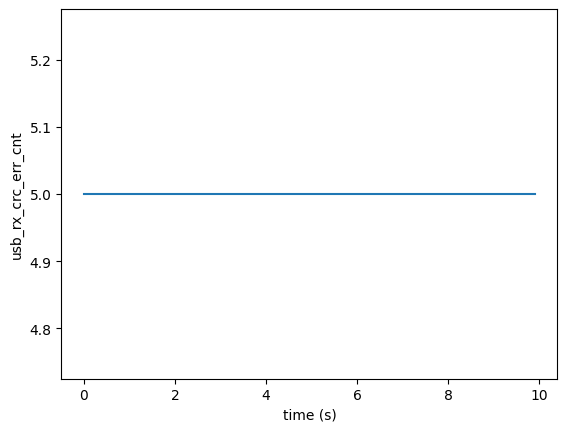

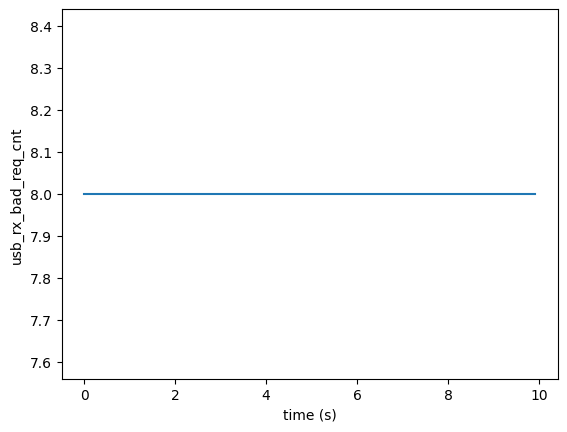

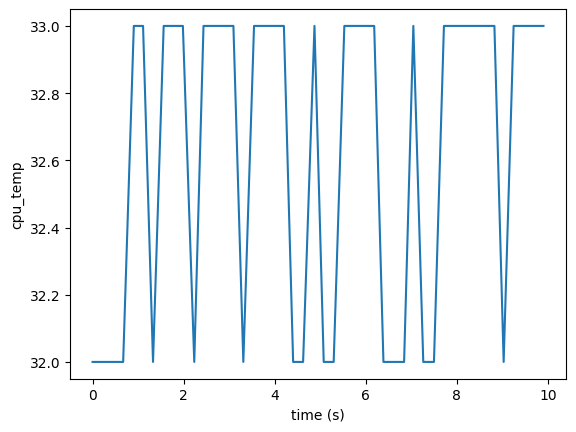

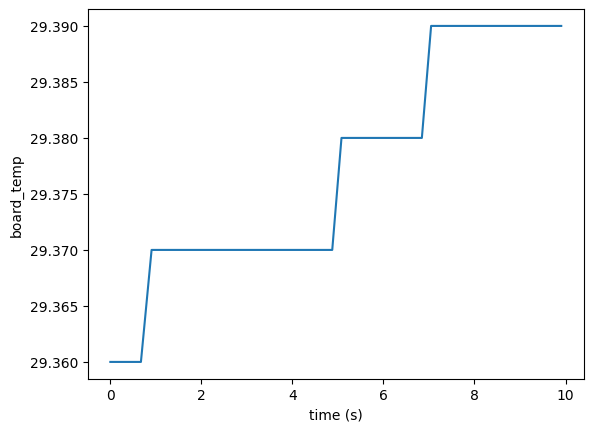

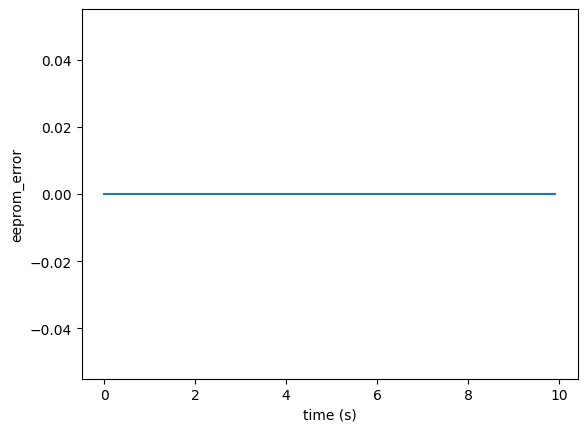

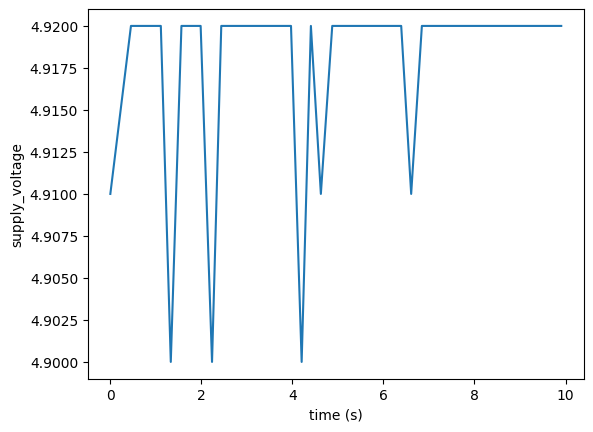

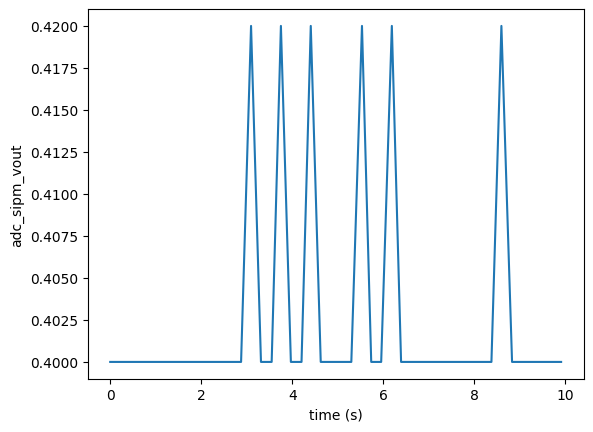

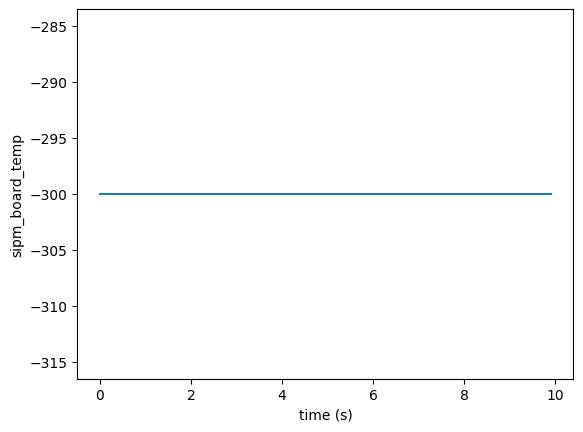

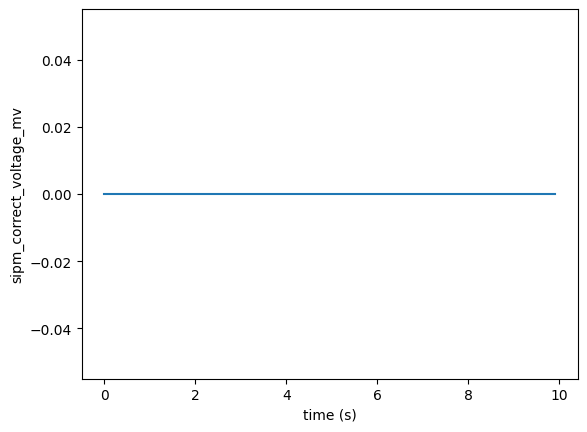

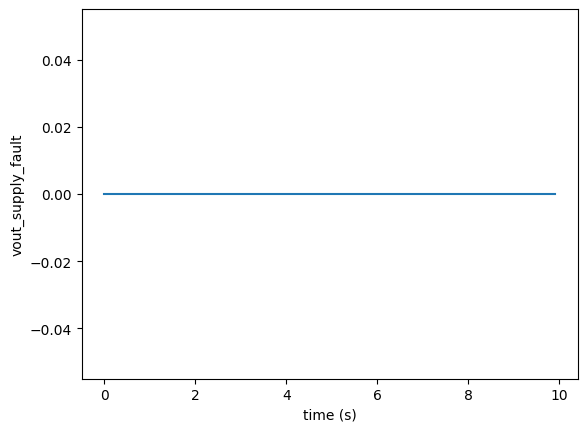

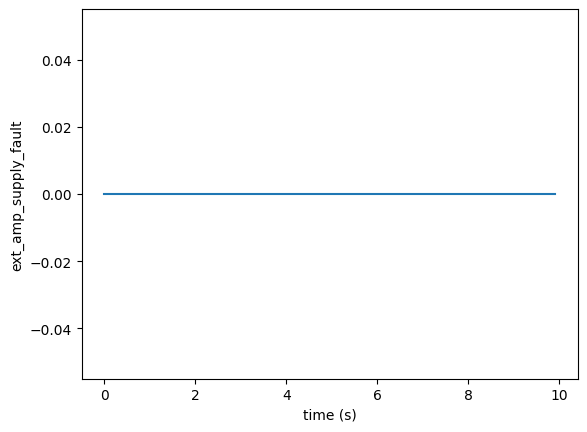

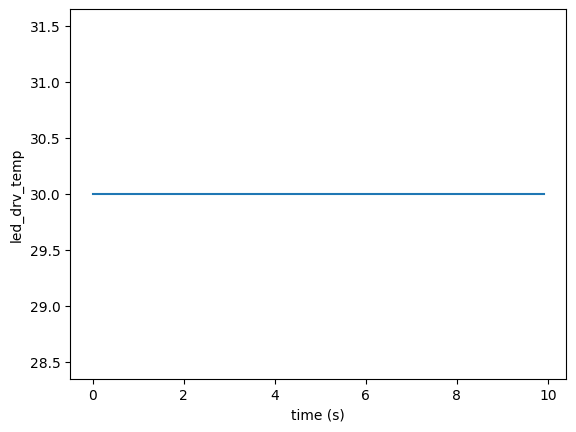

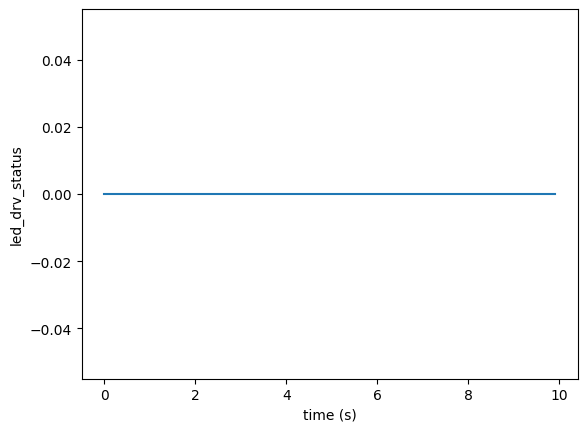

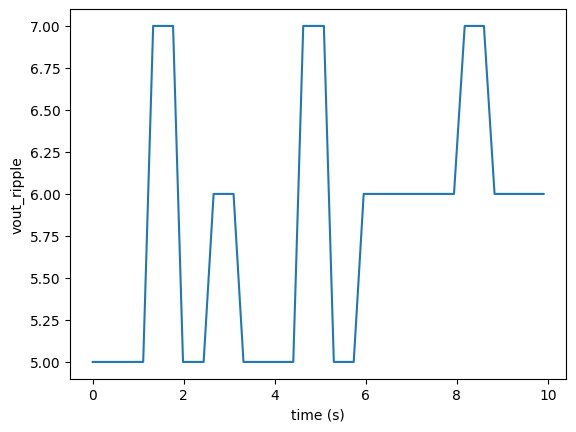

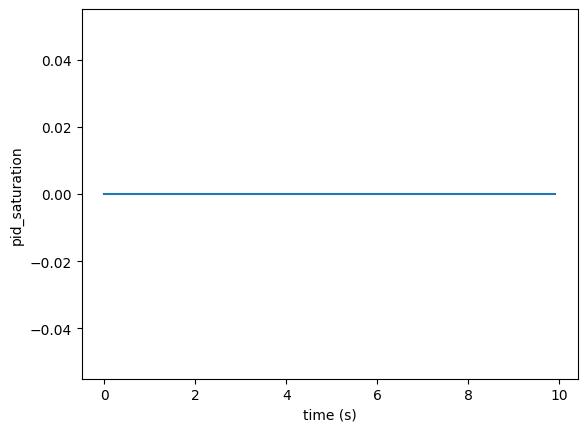

In [37]:
for key, values in buffer.items():
    plt.figure()
    plt.plot(times, values)
    plt.xlabel('time (s)')
    plt.ylabel(key)
    plt.show()

In [38]:
dt = np.array(times[1:]) - np.array(times[:-1])

(array([12.,  0.,  0.,  3., 15.,  0.,  0.,  7.,  4.,  0.,  0.,  0.,  2.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.203     , 0.20690625, 0.2108125 , 0.21471875, 0.218625  ,
        0.22253125, 0.2264375 , 0.23034375, 0.23425   , 0.23815625,
        0.2420625 , 0.24596875, 0.249875  , 0.25378125, 0.2576875 ,
        0.26159375, 0.2655    , 0.26940625, 0.2733125 , 0.27721875,
        0.281125  , 0.28503125, 0.2889375 , 0.29284375, 0.29675   ,
        0.30065625, 0.3045625 , 0.30846875, 0.312375  , 0.31628125,
        0.3201875 , 0.32409375, 0.328     , 0.33190625, 0.3358125 ,
        0.33971875, 0.343625  , 0.34753125, 0.3514375 , 0.35534375,
        0.35925   , 0.36315625, 0.3670625 , 0.37096875, 0.374875  ,
        0.37878125, 0.3826

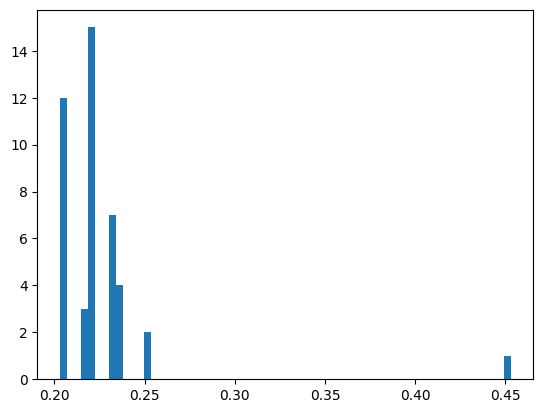

In [39]:
plt.hist(dt, bins=64)

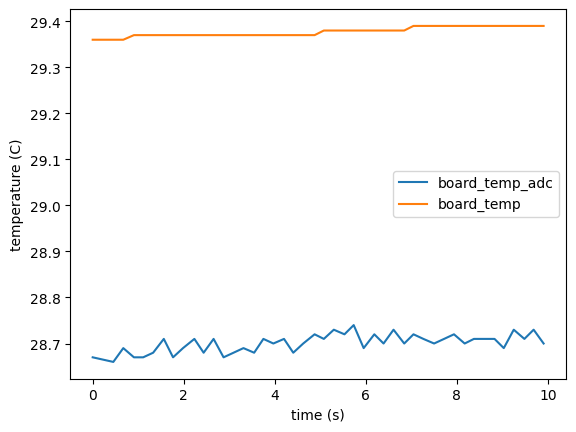

In [40]:
plt.figure()
for key, values in buffer.items():
    if 'board_temp' in key and 'sipm' not in key:
        plt.plot(times, np.array(values), label=key)
plt.xlabel('time (s)')
plt.ylabel('temperature (C)')
plt.legend()
plt.show()

In [ ]:
from nlab_modbus.discovery.scan import scan_local_modbus_devices, scan_remote_modbus_devices

In [42]:
mgr.close_all()

In [51]:
import asyncio

In [43]:
result = scan_local_modbus_devices()

2026-06-01 13:07:28,615 | INFO     | nlab_modbus.discovery.scan | Register found: 257


In [44]:
result

[{'type': <DeviceType.SIPM: 257>,
  'device_id': 1,
  'host': None,
  'port': 'COM6',
  'description': 'USB Serial Port (COM6)',
  'hardware_id': 257}]

In [47]:
ips = scan_remote_boards()

2026-06-01 13:08:35,021 | WARNING  | zeroconf | unregister_all_services skipped as it does blocking i/o; use AsyncZeroconf with asyncio


In [48]:
ips

[]

In [52]:
def scan_remote_ips(name="nucliflare"):
    """Sync-callable everywhere. Returns dict directly."""
    try:
        asyncio.get_running_loop()
    except RuntimeError:
        running_loop = False
    else:
        running_loop = True

    if running_loop:
        # Jupyter or qasync: can't block; caller should use the async variant.
        raise RuntimeError("Running loop detected — use `await self.scan_remote_ips_async(name)`.")
    # plain script / Qt worker thread: no loop, just run it
    return scan_remote_boards(name_filter=name)

RuntimeError: Running loop detected — use `await self.scan_remote_ips_async(name)`.

In [56]:
async def scan_remote_ips_async(name="nucliflare"):
    return await asyncio.to_thread(scan_remote_boards, name_filter=name)

In [59]:
ips = await mgr.scan_remote_ips_async()

In [60]:
ips

['192.168.10.134', '192.168.10.128']

In [61]:
results

NameError: name 'results' is not defined

In [62]:
result

[{'type': <DeviceType.SIPM: 257>,
  'device_id': 1,
  'host': None,
  'port': 'COM6',
  'description': 'USB Serial Port (COM6)',
  'hardware_id': 257}]

In [63]:
from nlab_modbus.core.enums import DeviceType

In [65]:
DeviceType(257).name

'SIPM'

In [78]:
available_devices = {'remote': {}, 'local': {}}

In [79]:
for item in result:
    port = item['port']
    dev_id = item['device_id']
    dev_name = DeviceType(item['hardware_id']).name
    if port not in available_devices['local']:
        available_devices['local'][port] = []
    available_devices['local'][port].append(f'{dev_id} {dev_name}')

In [80]:
available_devices

{'remote': {}, 'local': {'COM6': ['1 SIPM']}}

In [81]:
remotes = scan_remote_modbus_devices('192.168.10.134', 5001)

2026-06-01 13:58:07,086 | INFO     | nlab_modbus.discovery.scan | Register found: 769


In [82]:
remotes

[{'type': <DeviceType.PSU: 769>,
  'device_id': 1,
  'host': '192.168.10.134',
  'port': 5001}]

In [ ]:
remotes[0]['type']